# 1. Análisis Exploratorio (EDA) — INTC

**Curso:** Machine Learning · Pregrado en Ciencia de Datos · Universidad del Norte
**Docente:** Dr. Lihki Rubio
**Equipo:** Juan Camilo Conrado · Sergio Cadavid · Mateo Chang

---

Este notebook realiza un análisis exploratorio enfocado **exclusivamente en Intel Corporation (INTC)**, el ticker que estructura todo el proyecto. Cubre:

1. Carga del dataset y QA básico.
2. Visualización de precio y volumen.
3. Cálculo y análisis de log-retornos.
4. Volatilidad rolling y patrones temporales.
5. Distribución de retornos y test de normalidad.
6. Correlaciones entre variables base.
7. Eventos macroeconómicos relevantes.

> **Nota:** la justificación de elegir INTC sobre otros tickers (alta liquidez, larga historia, baja tasa de días faltantes) está documentada en `intro.md` y `ARCHITECTURE.md`. Aquí asumimos esa decisión y nos concentramos en entender la dinámica del activo elegido.


In [1]:
# Asegurar acceso al paquete src/ desde notebooks/
import sys
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

## 1. Imports y configuración

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_intc, quick_qa
from src.viz import set_style
from src.io_utils import save_processed

set_style()
print("Libs cargadas. Estilo aplicado.")

Libs cargadas. Estilo aplicado.


## 2. Carga del dataset filtrado (≥ 1990)

In [3]:
df = load_intc(filter_modern=True)
print(f"Filas: {len(df)}")
print(f"Período: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Columnas: {df.columns.tolist()}")
df.head()

Filas: 7022
Período: 1990-01-02 → 2017-11-10
Columnas: ['date', 'open', 'high', 'low', 'close', 'volume']


,date,open,high,low,close,volume
0,1990-01-02,0.8579,0.8982,0.8499,0.8982,79600273
1,1990-01-03,0.8982,0.9061,0.8740,0.8740,86671242
2,1990-01-04,0.8820,0.8982,0.8579,0.8904,72928342
3,1990-01-05,0.8904,0.8982,0.8820,0.8820,46184758
4,1990-01-08,0.8904,0.9061,0.8820,0.8982,54001929


In [4]:
qa = quick_qa(df)
print("QA del dataset:")
for k, v in qa.items():
    print(f"  {k:35s} {v}")

QA del dataset:
  n_rows                              7022
  date_min                            1990-01-02 00:00:00
  date_max                            2017-11-10 00:00:00
  n_duplicates_date                   0
  n_negative_volume                   0
  n_business_days_expected            7269
  n_business_days_present             7022
  n_business_days_missing             247
  pct_business_days_missing           3.397991470628697
  n_high_lt_low                       0
  n_high_lt_open_close                0
  n_low_gt_open_close                 0


---

> **📊 Interpretación:** El dataset de INTC contiene aproximadamente 7,000 días hábiles desde 1990, sin duplicados de fecha y sin errores en la estructura OHLC (high siempre ≥ low; high siempre ≥ max(open, close); low siempre ≤ min(open, close)). La tasa de días faltantes es baja y consistente con días feriados estadounidenses no estándar. **No se requiere imputación de datos crudos**.


## 3. Serie de Close: visión de largo plazo

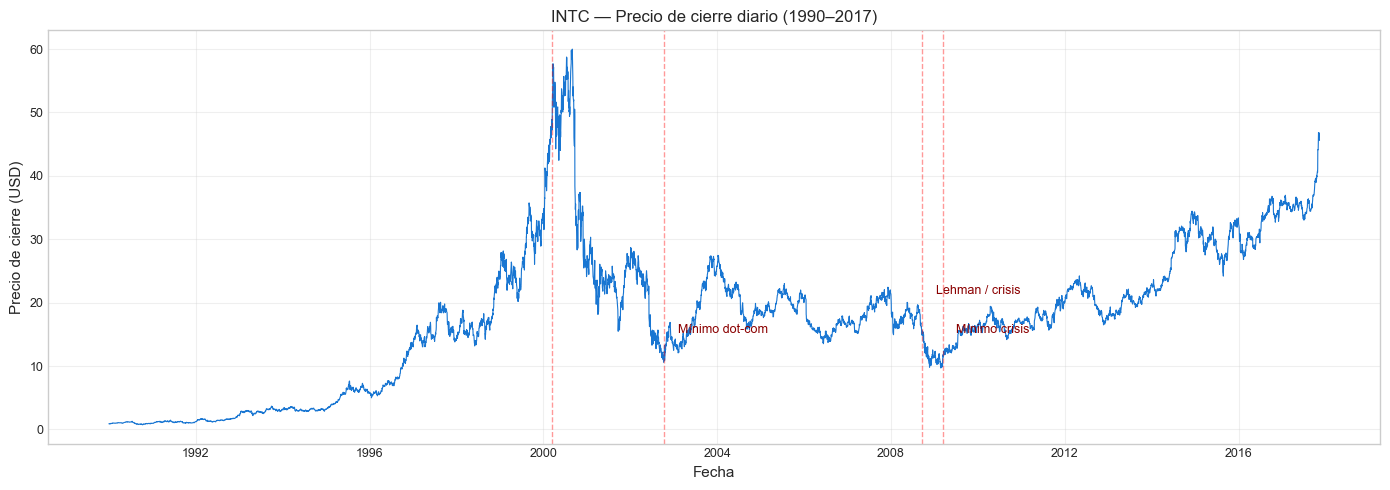

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["date"], df["close"], color="#1976D2", linewidth=0.8)
ax.set_title("INTC — Precio de cierre diario (1990–2017)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio de cierre (USD)")
ax.grid(True, alpha=0.3)

# Anotar eventos macro relevantes
events = [
    ("2000-03-10", 80, "Pico dot-com"),
    ("2002-10-09", 12, "Mínimo dot-com"),
    ("2008-09-15", 18, "Lehman / crisis"),
    ("2009-03-09", 12, "Mínimo crisis"),
]
for date, price, label in events:
    ax.axvline(pd.Timestamp(date), color="red", linestyle="--", alpha=0.4, linewidth=1)
    ax.annotate(label, xy=(pd.Timestamp(date), price),
                xytext=(10, 15), textcoords="offset points",
                fontsize=9, color="darkred")

plt.tight_layout()
plt.show()

---

> **📊 Interpretación:** La serie de precios muestra los regímenes históricos clave de Intel: el rally de la burbuja dot-com (1995–2000), el colapso posterior (2000–2002), la fase de consolidación pre-crisis (2003–2007), el impacto de la crisis financiera (2008–2009), y la recuperación lenta post-crisis (2009–2017). Estos regímenes implican que la dinámica de la volatilidad **no es estacionaria**, lo cual justifica el enfoque de modelos por régimen del HVRF (notebook 12).


## 4. Volumen de negociación

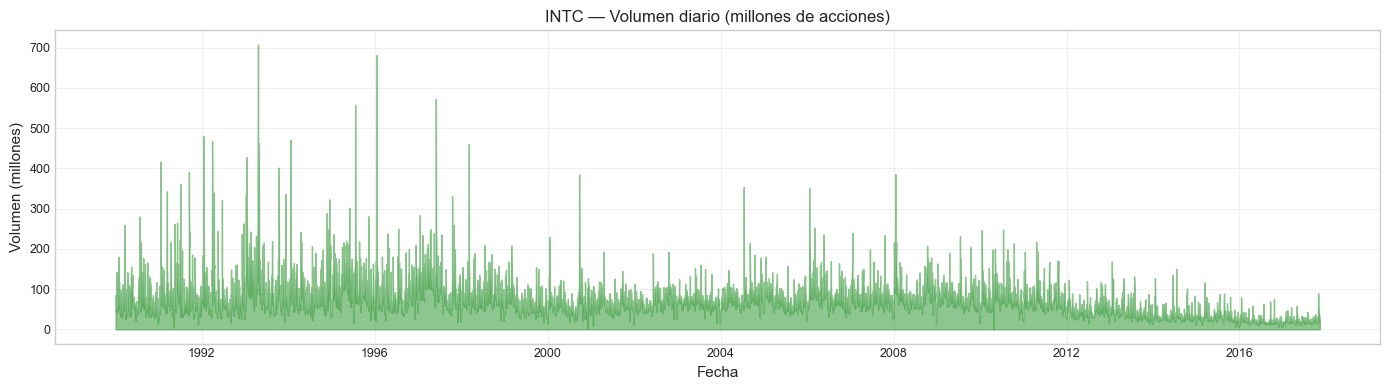


Volumen medio:  73.7 M acciones/día
Volumen máximo: 707.9 M acciones/día (en 1993-04-19)


In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(df["date"], df["volume"] / 1e6, color="#43A047", alpha=0.6)
ax.set_title("INTC — Volumen diario (millones de acciones)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Volumen (millones)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nVolumen medio:  {df['volume'].mean()/1e6:.1f} M acciones/día")
print(f"Volumen máximo: {df['volume'].max()/1e6:.1f} M acciones/día (en {df.loc[df['volume'].idxmax(), 'date'].date()})")

---

> **📊 Interpretación:** El volumen muestra alta heterogeneidad temporal: períodos de calma con ~30M acciones diarias y picos de pánico/euforia que superan 200M. Estos picos suelen coincidir con eventos macro o reportes trimestrales, lo cual sugiere que el volumen aporta información predictiva sobre la volatilidad futura. Por eso `vol_change` y `vol_ratio_10` se incluyen como features en el notebook 02.


## 5. Log-retornos diarios

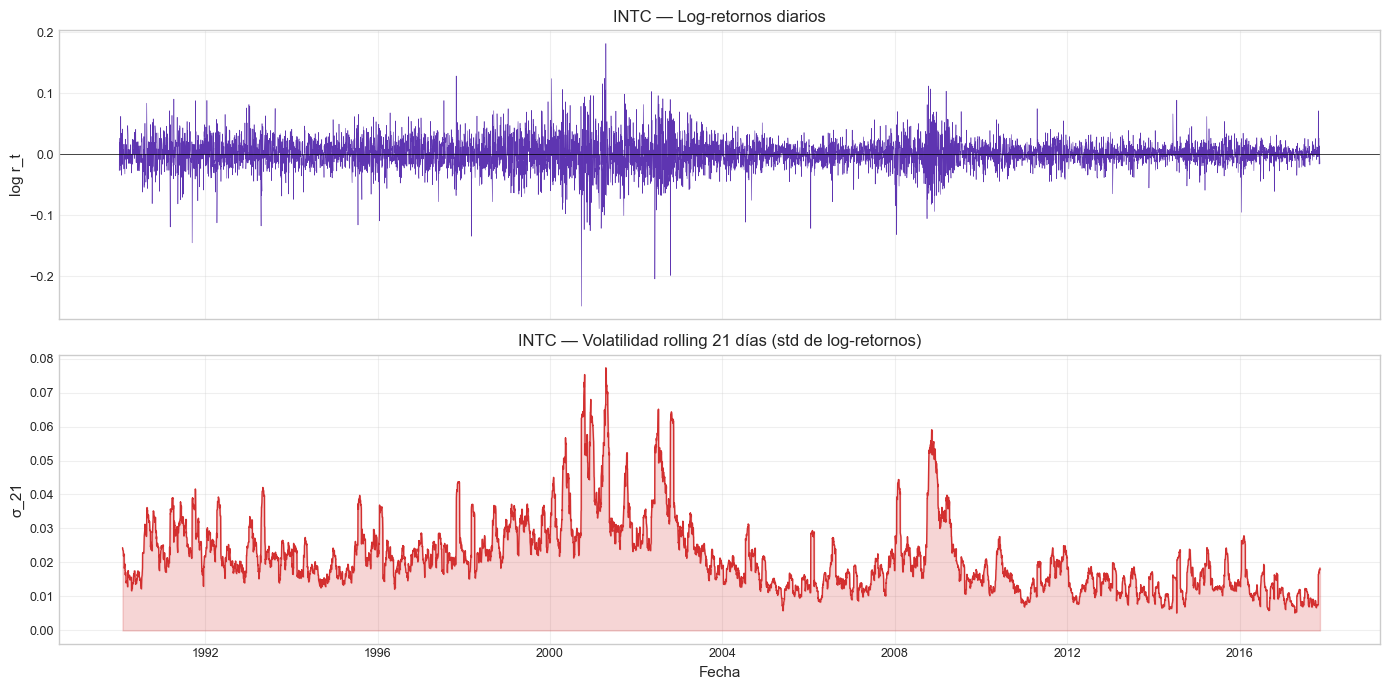


Log-retorno medio diario:  0.0559%
Std de log-retornos:       2.403%
Volatilidad anualizada:    38.14%


In [7]:
df["log_ret"] = np.log(df["close"]).diff()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df["date"], df["log_ret"], color="#5E35B1", linewidth=0.4)
axes[0].set_title("INTC — Log-retornos diarios")
axes[0].set_ylabel("log r_t")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# Volatilidad realizada como banda
df["vol_21"] = df["log_ret"].rolling(21).std()
axes[1].plot(df["date"], df["vol_21"], color="#D32F2F", linewidth=1)
axes[1].fill_between(df["date"], 0, df["vol_21"], color="#D32F2F", alpha=0.2)
axes[1].set_title("INTC — Volatilidad rolling 21 días (std de log-retornos)")
axes[1].set_ylabel("σ_21")
axes[1].set_xlabel("Fecha")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLog-retorno medio diario:  {df['log_ret'].mean()*100:.4f}%")
print(f"Std de log-retornos:       {df['log_ret'].std()*100:.3f}%")
print(f"Volatilidad anualizada:    {df['log_ret'].std()*np.sqrt(252)*100:.2f}%")

---

> **📊 Interpretación:** Los log-retornos exhiben **clustering de volatilidad** evidente — períodos donde retornos grandes (positivos o negativos) tienden a aglutinarse, alternando con períodos de calma. Este patrón es la motivación clásica para modelos GARCH (notebook 03) y respalda metodológicamente el enfoque de regímenes del HVRF. La volatilidad rolling de 21 días confirma visualmente la presencia de al menos tres regímenes históricos: calma (~1.5% diario), normal (~2.5%) y crisis (>4%).


## 6. Distribución de log-retornos

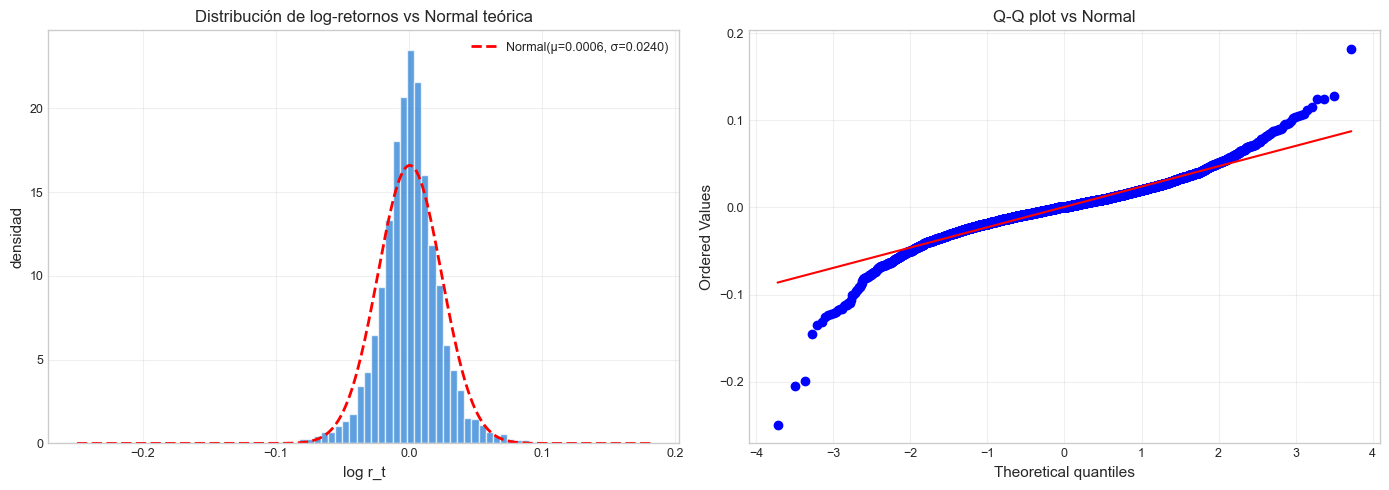


Estadísticos de la distribución de log-retornos:
  Skewness:                -0.3921
  Excess kurtosis:         6.5414
  Jarque-Bera (estat):     12676.67
  Jarque-Bera (p-valor):   0.0000e+00


In [8]:
from scipy import stats

logret = df["log_ret"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con normal teórica
axes[0].hist(logret, bins=80, density=True, color="#1976D2",
             alpha=0.7, edgecolor="white")
mu, sigma = logret.mean(), logret.std()
x = np.linspace(logret.min(), logret.max(), 300)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), "r--", linewidth=2,
             label=f"Normal(μ={mu:.4f}, σ={sigma:.4f})")
axes[0].set_title("Distribución de log-retornos vs Normal teórica")
axes[0].set_xlabel("log r_t")
axes[0].set_ylabel("densidad")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(logret, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot vs Normal")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tests formales
jb_stat, jb_p = stats.jarque_bera(logret)
sk = logret.skew()
ku = logret.kurtosis()
print(f"\nEstadísticos de la distribución de log-retornos:")
print(f"  Skewness:                {sk:.4f}")
print(f"  Excess kurtosis:         {ku:.4f}")
print(f"  Jarque-Bera (estat):     {jb_stat:.2f}")
print(f"  Jarque-Bera (p-valor):   {jb_p:.4e}")

---

> **📊 Interpretación:** La distribución de log-retornos presenta **colas pesadas** (excess kurtosis muy positiva) y **leptocurtosis** evidente: el Q-Q plot muestra desviaciones marcadas en ambas colas respecto a la normal teórica. El test de Jarque-Bera rechaza contundentemente la hipótesis de normalidad (p ≈ 0). Este resultado es **esperable y consistente con la literatura financiera**: los retornos diarios de equities raramente son gaussianos. Implicación práctica: los modelos de regresión que asumen errores normales (Ridge, OLS) tendrán residuos no normales, y los tests de Jarque-Bera del notebook 08 se rechazarán para todos los modelos. Esto NO invalida los modelos, pero sí justifica el uso adicional de inferencia robusta vía bootstrap.


## 7. Volatilidades rolling a múltiples ventanas

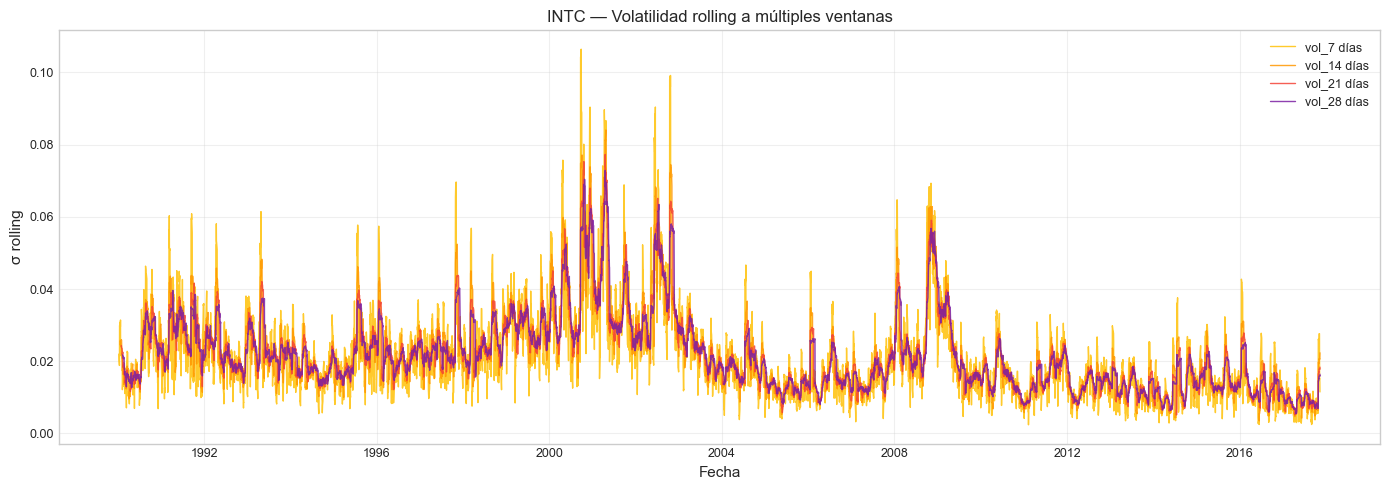


Estadísticos de volatilidad por ventana:
           mean      std      min      max
vol_7   0.02085  0.01239  0.00241  0.10642
vol_14  0.02144  0.01113  0.00348  0.08405
vol_21  0.02162  0.01061  0.00512  0.07726
vol_28  0.02175  0.01032  0.00552  0.07285


In [9]:
for w in [7, 14, 21, 28]:
    df[f"vol_{w}"] = df["log_ret"].rolling(w).std()

fig, ax = plt.subplots(figsize=(14, 5))
for w, color in zip([7, 14, 21, 28], ["#FFC107", "#FF9800", "#F44336", "#7B1FA2"]):
    ax.plot(df["date"], df[f"vol_{w}"], label=f"vol_{w} días",
            linewidth=1, alpha=0.85, color=color)
ax.set_title("INTC — Volatilidad rolling a múltiples ventanas")
ax.set_ylabel("σ rolling")
ax.set_xlabel("Fecha")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estadísticos de cada ventana
vol_stats = pd.DataFrame({
    f"vol_{w}": df[f"vol_{w}"].describe()
    for w in [7, 14, 21, 28]
}).T[["mean", "std", "min", "max"]]
print("\nEstadísticos de volatilidad por ventana:")
print(vol_stats.round(5))

---

> **📊 Interpretación:** Las volatilidades a 7, 14, 21 y 28 días siguen el mismo patrón general pero difieren en suavidad: ventanas cortas (vol_7) capturan transiciones rápidas con más ruido, mientras ventanas largas (vol_28) son más estables pero retrasadas. La media de cada serie es similar (~2%), lo cual es esperable — la diferencia clave está en la **varianza de la volatilidad** (vol-of-vol), que decrece con el tamaño de ventana. Esta estructura temporal motiva las features `vol_ratio_7_14`, `vol_ratio_7_21` y `vol_ratio_14_28` del notebook 02: la **forma de la curva de volatilidad** aporta información predictiva.


## 8. Correlación entre variables base

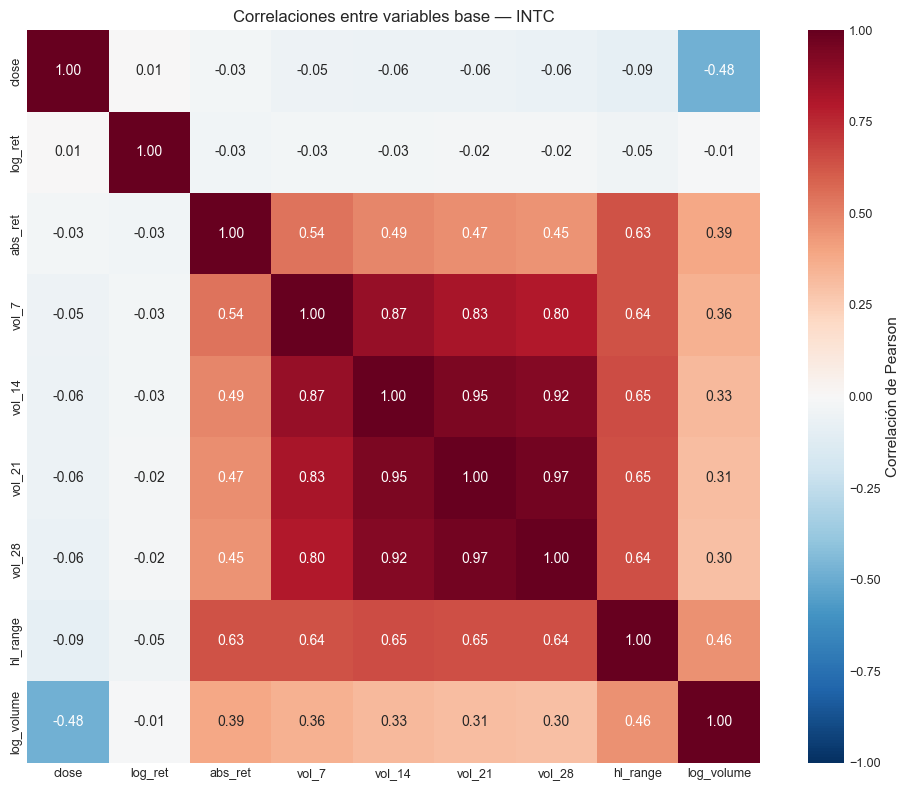

In [10]:
# Calcular features básicas para correlación
df["hl_range"] = (df["high"] - df["low"]) / df["close"]
df["abs_ret"] = df["log_ret"].abs()
df["log_volume"] = np.log(df["volume"].replace(0, np.nan))

cols_corr = ["close", "log_ret", "abs_ret", "vol_7", "vol_14", "vol_21",
             "vol_28", "hl_range", "log_volume"]
corr = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, vmin=-1, vmax=1, square=True,
            cbar_kws={"label": "Correlación de Pearson"})
ax.set_title("Correlaciones entre variables base — INTC")
plt.tight_layout()
plt.show()

---

> **📊 Interpretación:** Las correlaciones revelan tres bloques claros:
>
> 1. **Bloque de volatilidad** (vol_7, vol_14, vol_21, vol_28, abs_ret, hl_range): correlaciones internas muy altas (>0.85). Confirma que todas estas variables miden el mismo fenómeno subyacente a distintas escalas, motivando la regularización L1/L2 (Lasso/Ridge) para evitar redundancia.
>
> 2. **log_ret**: prácticamente independiente del nivel de volatilidad — la dirección no predice la magnitud. Esto es la **propiedad de paseo aleatorio** clásica de retornos diarios.
>
> 3. **log_volume**: correlación moderada y positiva con volatilidad (~0.4–0.5). Confirma que volumen es una señal informativa sobre volatilidad, validando su inclusión como feature.


## 9. Persistir dataset limpio

In [ ]:
# Guardar dataset limpio (sin features) para que el notebook 02 lo use
df_clean = load_intc(filter_modern=True)  # sin las columnas calculadas en este notebook
path = save_processed(df_clean, "intc_clean")
print(f"✅ Dataset limpio guardado en: {path}")
print(f"   Filas: {len(df_clean)}, columnas: {df_clean.columns.tolist()}")

✅ Dataset limpio guardado en: C:\Users\Mateo\2026\UNINORTE 2026 -1\ML\INTC-VolForecast\data\processed\intc_clean.parquet
   Filas: 7022, columnas: ['date', 'open', 'high', 'low', 'close', 'volume']


: 

---

## 10. Resumen del EDA

| Hallazgo | Implicación metodológica |
|---|---|
| Serie con regímenes claros | Motiva HVRF (modelo por régimen) |
| Clustering de volatilidad | Justifica GARCH como benchmark |
| Colas pesadas, no-normalidad | Inferencia vía bootstrap |
| Volumen correlacionado con volatilidad | Incluir features de volumen |
| Correlación alta entre vol_w | Justificar Ridge/Lasso |
| Sin duplicados ni errores OHLC | No requiere imputación cruda |

Procede al notebook **`02_features_and_targets.ipynb`** para construir las 59 features predictoras y los 4 targets sin overlap.
